# Gradient Boosting Machine dùng Scikit Learn

In [21]:
import time
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Import class GradientBoostingClassifier từ SKLEARN
from sklearn.ensemble import GradientBoostingClassifier

# 1. load & kiểm tra dữ liệu

In [2]:
print("Đang tải dữ liệu...")
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

df.sample(5)   # random 5 dòng

Đang tải dữ liệu...


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
475,12.83,15.73,82.89,506.9,0.09040,0.08269,0.05835,0.03078,0.1705,0.05913,...,14.09,19.35,93.22,605.8,0.1326,0.2610,0.3476,0.09783,0.3006,0.07802
283,16.24,18.77,108.80,805.1,0.10660,0.18020,0.19480,0.09052,0.1876,0.06684,...,18.55,25.09,126.90,1031.0,0.1365,0.4706,0.5026,0.17320,0.2770,0.10630
84,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
215,13.86,16.93,90.96,578.9,0.10260,0.15170,0.09901,0.05602,0.2106,0.06916,...,15.75,26.93,104.40,750.1,0.1460,0.4370,0.4636,0.16540,0.3630,0.10590
482,13.47,14.06,87.32,546.3,0.10710,0.11550,0.05786,0.05266,0.1779,0.06639,...,14.83,18.32,94.94,660.2,0.1393,0.2499,0.1848,0.13350,0.3227,0.09326


In [3]:
print(df.shape)

(569, 30)


In [4]:
print(df.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# 2. Chia tập dữ liệu (80% train, 20% test)

In [7]:
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


   # 3. Chuẩn hóa dữ liệu 
    * Thực tế các mô hình dạng Tree không quá nhạy cảm với scale

In [8]:
print("Đang chuẩn hóa dữ liệu...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Đang chuẩn hóa dữ liệu...


 # 4. Khởi tạo mô hình bằng code của bạn
     Set n_estimators nhỏ (10) và max_depth nhỏ (2) để tránh việc phải đợi quá lâu

In [25]:
clf = GradientBoostingClassifier(
    n_estimators=10, 
    learning_rate=0.1, 
    max_depth=2
)
print("\n\nĐã khởi tạo Gradient Boosting (sklearn)")



Đã khởi tạo Gradient Boosting (sklearn)


# 5. Huấn luyện mô hình

In [10]:
print("\n\nBắt đầu quá trình huấn luyện (vui lòng đợi một lát do thuật toán chia node đang dùng vòng lặp Python)...")
start_time = time.time()

clf.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"\n[+] Huấn luyện hoàn tất trong {train_time:.2f} giây.")



Bắt đầu quá trình huấn luyện (vui lòng đợi một lát do thuật toán chia node đang dùng vòng lặp Python)...

[+] Huấn luyện hoàn tất trong 0.11 giây.


# 6. Dự đoán trên tập Test

In [19]:
print("Đang dự đoán trên tập kiểm tra...")
y_pred = clf.predict(X_test_scaled)
print("\n5 dự đoán mẫu")
print("\nDự đoán:")
print(y_pred[:5])
print("\n\ntrue:")
print(y_test[:5])

Đang dự đoán trên tập kiểm tra...

5 dự đoán mẫu

Dự đoán:
[1 0 0 1 1]


true:
[1 0 0 1 1]


# 7. Đánh giá và báo cáo


         KẾT QUẢ ĐÁNH GIÁ (TEST SET)
Accuracy Score: 95.61%


Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:


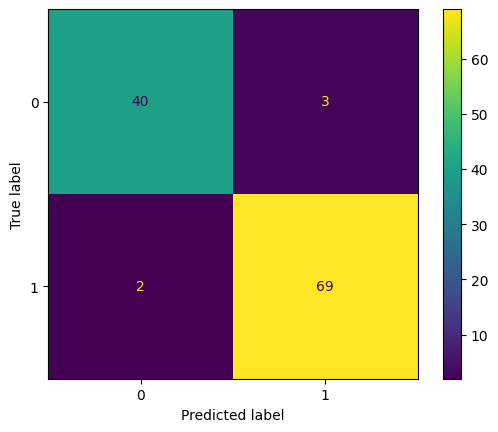

In [24]:
print("\n" + "="*40)
print("         KẾT QUẢ ĐÁNH GIÁ (TEST SET)")
print("="*40)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {acc * 100:.2f}%\n")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()